# DBSCAN Density-Based Spatial Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups coordinates based on local point densities. Unlike K-Means, DBSCAN does not assume spherical clusters or require specifying the number of clusters beforehand. It automatically isolates low-density noise points as outliers. This notebook generates synthetic multi-shape structures (concentric rings and blobs), applies DBSCAN, and visualizes outcomes using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles, make_blobs

# Generate synthetic composite coordinates (200 concentric circle points, 200 clustered blob points)
np.random.seed(188)
n_samples = 200

# 1. Concentric circles (2 clusters)
X_circles, _ = make_circles(n_samples=n_samples, factor=0.5, noise=0.06, random_state=42)
X_circles = X_circles * 1.5 - 1.0 # Shift and scale

# 2. Clustered blobs (2 clusters)
X_blobs, _ = make_blobs(n_samples=n_samples, centers=[[3.0, 3.0], [3.0, -3.0]], cluster_std=0.45, random_state=42)

X = np.vstack((X_circles, X_blobs))

df_db = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df_db.head(10)



,Feature_1,Feature_2
0,0.374861,-1.501460
1,-0.087738,0.212861
2,-1.394469,0.323103
3,-1.727010,-1.291733
4,-1.212700,-0.138723
5,-0.432693,-0.267928
6,-1.631445,-2.387744
7,-1.276172,-1.630208
8,-0.893498,-1.669897
9,-2.425762,-0.569373


## DBSCAN Clustering Fitting

We fit a DBSCAN model specifying search radius epsilon=0.35 and minimum core neighbors min_samples=5.



In [2]:
dbscan = DBSCAN(eps=0.35, min_samples=5)
labels = dbscan.fit_predict(X)

# Calculate cluster properties
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated Number of Clusters: {n_clusters}")
print(f"Estimated Number of Noise Points (Outliers): {n_noise}/{len(X)}")



Estimated Number of Clusters: 3
Estimated Number of Noise Points (Outliers): 9/400


## Clustering Partitions & Outliers Map

Using Matplotlib, we scatter clustered coordinates, coloring distinct clusters and highlighting noise outliers (label -1) in black.



<cell>:21: UserWarning:

You passed an edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.

<cell>:38: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



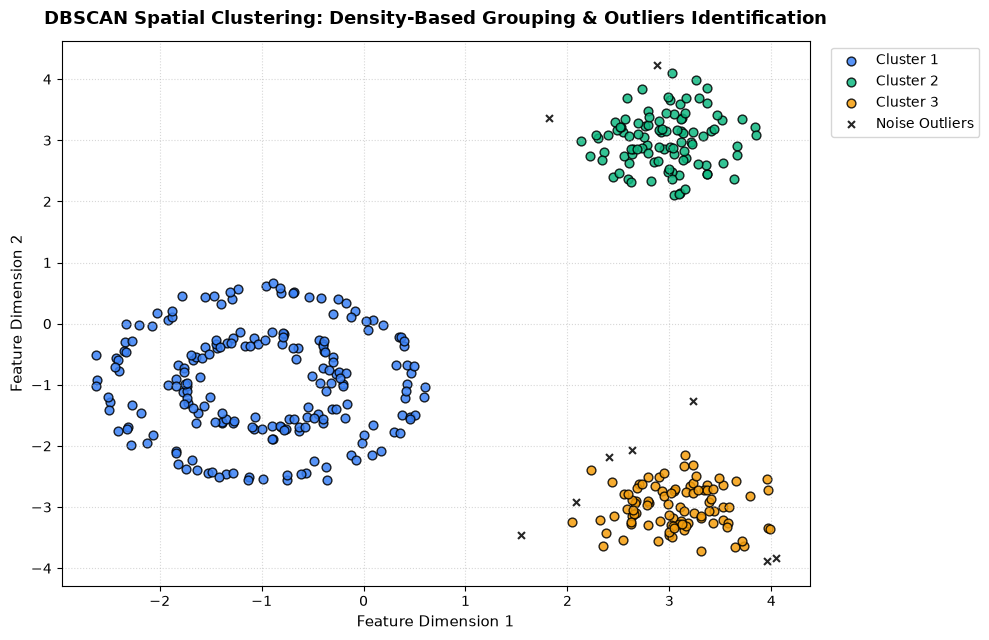

In [3]:
plt.figure(figsize=(10, 6.5))

# Determine color cycles for clusters
colors_list = ['black', '#3B82F6', '#10B981', '#F59E0B', '#EC4899']

for k in unique_labels:
    class_member_mask = (labels == k)
    
    # Noise points (outliers) colored black
    if k == -1:
        color = 'black'
        marker = 'x'
        size = 25
        label = 'Noise Outliers'
    else:
        color = colors_list[(k + 1) % len(colors_list)]
        marker = 'o'
        size = 40
        label = f'Cluster {k+1}'
        
    plt.scatter(
        X[class_member_mask, 0], 
        X[class_member_mask, 1], 
        c=[color], 
        marker=marker, 
        s=size,
        edgecolors='k' if k != -1 else 'none',
        alpha=0.85,
        label=label
    )

plt.title('DBSCAN Spatial Clustering: Density-Based Grouping & Outliers Identification', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Feature Dimension 1', fontsize=11)
plt.ylabel('Feature Dimension 2', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
